In [1]:
import pandas as pd

df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [3]:
df['Class'].value_counts()
print(f"\nPorcentaje de fraude: {df['Class'].mean()*100:.3f}%")


Porcentaje de fraude: 0.173%


In [4]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

## Análisis Exploratorio

Dataset con fuerte desbalanceo de clases (0.173% fraude), típico en problemas de detección de fraude. 
Este desbalanceo va a condicionar todas las decisiones metodológicas posteriores (métricas, 
manejo de clases, umbral de decisión).

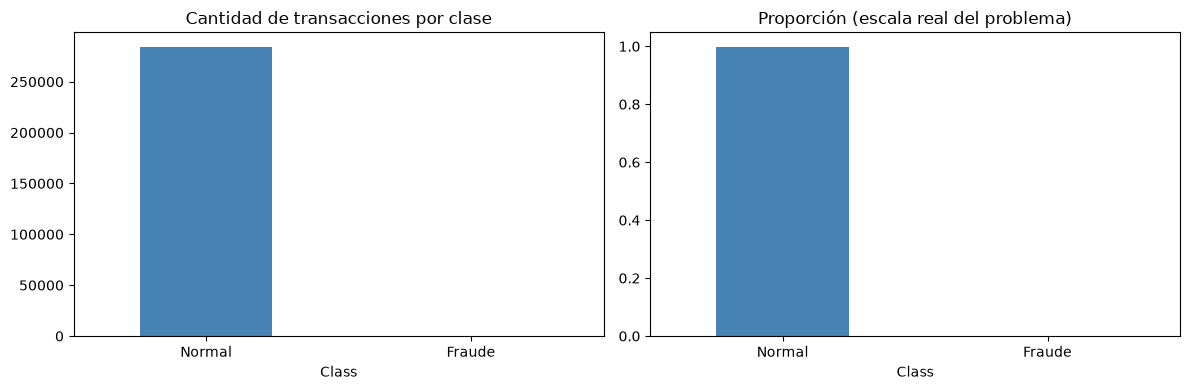

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df['Class'].value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'crimson'])
ax[0].set_title('Cantidad de transacciones por clase')
ax[0].set_xticklabels(['Normal', 'Fraude'], rotation=0)

df['Class'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['steelblue', 'crimson'])
ax[1].set_title('Proporción (escala real del problema)')
ax[1].set_xticklabels(['Normal', 'Fraude'], rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_12006/529693888.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(['Normal', 'Fraude'])
/tmp/ipykernel_12006/529693888.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[1].set_xticklabels(['Normal', 'Fraude'])


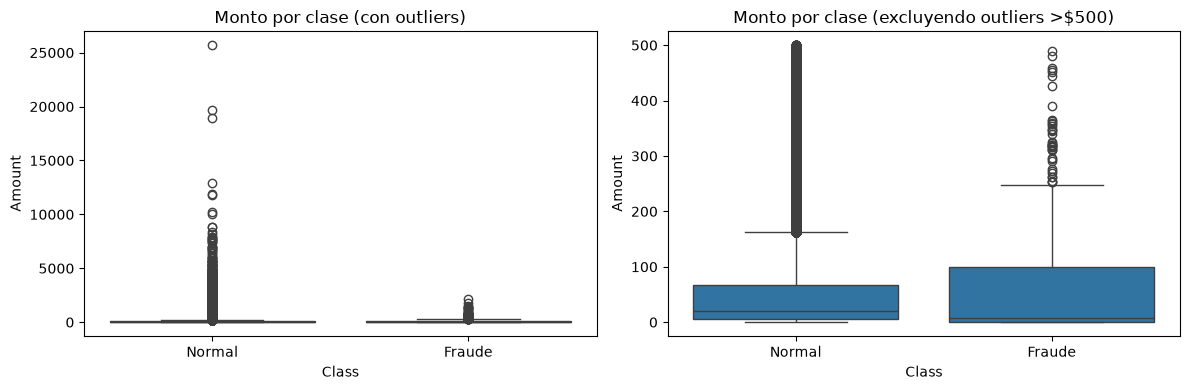

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Class', y='Amount', data=df, ax=ax[0])
ax[0].set_title('Monto por clase (con outliers)')
ax[0].set_xticklabels(['Normal', 'Fraude'])

sns.boxplot(x='Class', y='Amount', data=df[df['Amount'] < 500], ax=ax[1])
ax[1].set_title('Monto por clase (excluyendo outliers >$500)')
ax[1].set_xticklabels(['Normal', 'Fraude'])

plt.tight_layout()
plt.show()

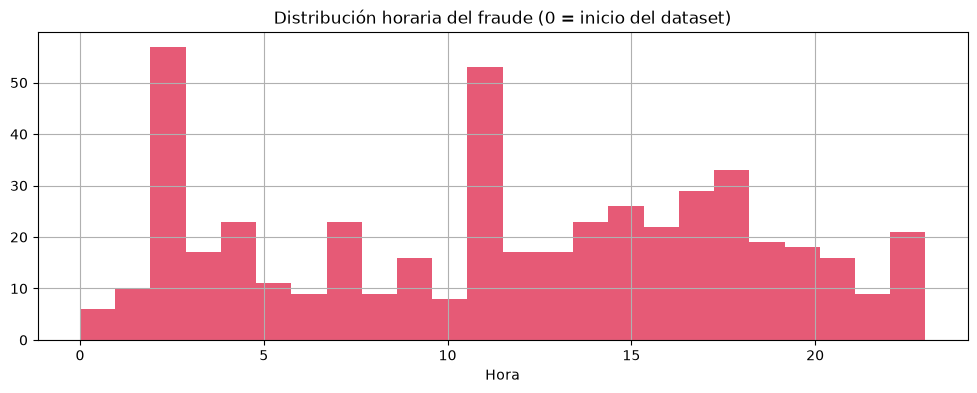

In [7]:
df['Hour'] = (df['Time'] // 3600) % 24

fig, ax = plt.subplots(figsize=(12, 4))
df[df['Class']==1]['Hour'].hist(bins=24, ax=ax, color='crimson', alpha=0.7)
ax.set_title('Distribución horaria del fraude (0 = inicio del dataset)')
ax.set_xlabel('Hora')
plt.show()

## Conclusiones del EDA

**Desbalanceo extremo de clases**
El fraude representa apenas 0.173% de las transacciones (492 de 284.807). La clase fraude es 
prácticamente invisible en un gráfico de barras estándar — esto confirma que accuracy es una 
métrica inútil para este problema: un modelo que jamás prediga fraude alcanzaría 99.8% de accuracy 
sin detectar un solo caso real.

**Los montos de fraude no son sistemáticamente más altos, pero sí más dispersos**
Excluyendo outliers extremos (>$500), las transacciones normales muestran una mediana baja (~$22) 
y una caja (IQR) más angosta, concentrada en montos chicos. Las transacciones fraudulentas, en 
cambio, muestran una caja más ancha con el percentil 75 llegando a ~$100 — es decir, el fraude 
tiende a distribuirse en un rango más amplio de montos, en vez de concentrarse en un ticket 
promedio bajo como las transacciones normales. Esto sugiere que `Amount` por sí solo no separa 
bien las clases, pero su variabilidad relativa sí podría ser una señal útil combinada con otras 
variables.

**Patrón horario del fraude: picos fuera del horario comercial estándar**
El fraude se concentra en dos franjas horarias marcadas: entre las 2 y 4 h, y nuevamente entre 
las 10 y 12 h — es decir, la mayor concentración de fraude ocurre antes del mediodía, con un pico 
particularmente llamativo en horas de madrugada (2-4h), un horario de menor actividad y monitoreo 
humano típico. Esto es consistente con patrones de fraude documentados en la industria, donde los 
actores maliciosos explotan ventanas de menor vigilancia. `Hour` (derivada de `Time`) es candidata 
fuerte como feature para el modelo.

## Split Temporal (no aleatorio)

A diferencia del enfoque estándar de `train_test_split` aleatorio, acá se usa un split temporal: 
se entrena con el 80% de transacciones más antiguas y se evalúa con el 20% más reciente.

Esto simula un escenario realista de producción: un banco nunca entrena con datos del futuro 
para predecir el pasado. Un split aleatorio filtraría información temporal y generaría 
métricas optimistas que no se sostienen en un despliegue real.

In [8]:
df_sorted = df.sort_values('Time').reset_index(drop=True)

split_point = int(len(df_sorted) * 0.8)
train = df_sorted.iloc[:split_point]
test = df_sorted.iloc[split_point:]

print(f"Train: {len(train)} transacciones, {train['Class'].sum()} fraudes ({train['Class'].mean()*100:.3f}%)")
print(f"Test:  {len(test)} transacciones, {test['Class'].sum()} fraudes ({test['Class'].mean()*100:.3f}%)")

Train: 227845 transacciones, 417 fraudes (0.183%)
Test:  56962 transacciones, 75 fraudes (0.132%)


**Hallazgo:** la proporción de fraude cae de 0.183% en el período de entrenamiento a 0.132% en 
el período de test (una reducción relativa de ~28%). Esto confirma que el fraude no está 
distribuido uniformemente en el tiempo dentro de esta ventana de 2 días, y refuerza por qué 
un split aleatorio habría sido metodológicamente más débil: mezclar ambos períodos ocultaría 
esta deriva temporal (data drift) que un modelo en producción sí enfrentaría.

In [9]:
feature_cols = [col for col in df.columns if col not in ['Class', 'Time']]

X_train = train[feature_cols]
y_train = train['Class']
X_test = test[feature_cols]
y_test = test['Class']

X_train.shape, X_test.shape

((227845, 30), (56962, 30))

## Modelado

Se entrena un modelo de clasificación (Random Forest) tratando el desbalanceo con `class_weight`, 
en vez de técnicas de oversampling como SMOTE. Se prioriza este enfoque porque SMOTE genera 
transacciones sintéticas interpolando entre casos de fraude reales — en un dominio donde las 
variables ya están anonimizadas via PCA (V1-V28), interpolar puede generar registros sin sentido 
físico real. `class_weight='balanced'` penaliza los errores en la clase minoritaria sin fabricar 
datos artificiales.

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

## Evaluación con métricas robustas a desbalanceo

Se evalúa con Precision-Recall AUC en lugar de ROC-AUC o accuracy. Con un desbalanceo de 
0.17%, ROC-AUC puede dar valores engañosamente altos incluso con modelos mediocres, porque 
la clase mayoritaria domina el cálculo. PR-AUC es sensible específicamente al desempeño 
sobre la clase minoritaria (fraude), que es la que realmente importa en este problema.

In [11]:
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    classification_report, roc_auc_score
)
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"PR-AUC:  {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("\n--- Classification Report (threshold=0.5 default) ---")
print(classification_report(y_test, model.predict(X_test), target_names=['Normal', 'Fraude']))

PR-AUC:  0.8123
ROC-AUC: 0.9859

--- Classification Report (threshold=0.5 default) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56887
      Fraude       0.84      0.76      0.80        75

    accuracy                           1.00     56962
   macro avg       0.92      0.88      0.90     56962
weighted avg       1.00      1.00      1.00     56962



## Resultados iniciales (threshold=0.5)

Con el split temporal (más exigente que un split aleatorio), el modelo alcanza PR-AUC de 0.81 
y ROC-AUC de 0.99. En términos de negocio: detecta el 76% de los fraudes reales (57 de 75 casos 
en el set de test) con una precisión de 84% (bajo nivel de falsas alarmas).

Sin embargo, el threshold de 0.5 usado por defecto no tiene ninguna justificación de negocio — 
es simplemente el punto medio matemático. El siguiente paso ajusta este umbral en base al costo 
real de cada tipo de error para el banco.

## Optimización del umbral por costo de negocio

En vez de usar el threshold 0.5 por defecto, se calcula el umbral que minimiza el costo total 
esperado para el banco, asumiendo:
- Costo de un Falso Negativo (fraude no detectado) = monto promedio de la transacción fraudulenta no detectada
- Costo de un Falso Positivo (cliente legítimo bloqueado) = costo fijo de revisión manual + fricción (estimado)

In [12]:
import numpy as np
avg_fraud_amount = test[test['Class']==1]['Amount'].mean()
cost_fn = avg_fraud_amount  # se pierde el monto completo del fraude
cost_fp = 5  # costo estimado de revisión manual de una transacción legítima marcada como sospechosa

print(f"Costo estimado por Falso Negativo (fraude no detectado): ${cost_fn:.2f}")
print(f"Costo estimado por Falso Positivo (revisión manual): ${cost_fp:.2f}")

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    total_cost = fn * cost_fn + fp * cost_fp
    costs.append(total_cost)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
print(f"\nThreshold óptimo: {best_threshold:.2f}")
print(f"Costo total con threshold óptimo: ${costs[best_idx]:,.2f}")
print(f"Costo total con threshold=0.50: ${costs[49]:,.2f}")

Costo estimado por Falso Negativo (fraude no detectado): $103.06
Costo estimado por Falso Positivo (revisión manual): $5.00

Threshold óptimo: 0.33
Costo total con threshold óptimo: $1,654.74
Costo total con threshold=0.50: $1,910.02


## Resultado: ahorro por optimización de threshold

Ajustar el umbral de decisión de 0.50 (default) a 0.33 (óptimo por costo) reduce el costo total 
esperado de $1.910,02 a $1.654,74 — un ahorro de $255,28 (13,4%) solo en el período de test 
(2 días de datos). Esto ocurre porque, dado que el costo de un fraude no detectado ($103 promedio) 
es mucho mayor al costo de una revisión manual ($5), conviene ser más agresivo detectando fraude 
aunque eso genere más falsas alarmas — el modelo debe "gritar fraude" con menos certeza de la que 
pediría un threshold neutral.

Extrapolado a un año completo, este ajuste representaría un ahorro proporcional significativo, 
sin necesidad de reentrenar el modelo — solo cambiando cómo se interpreta su output.

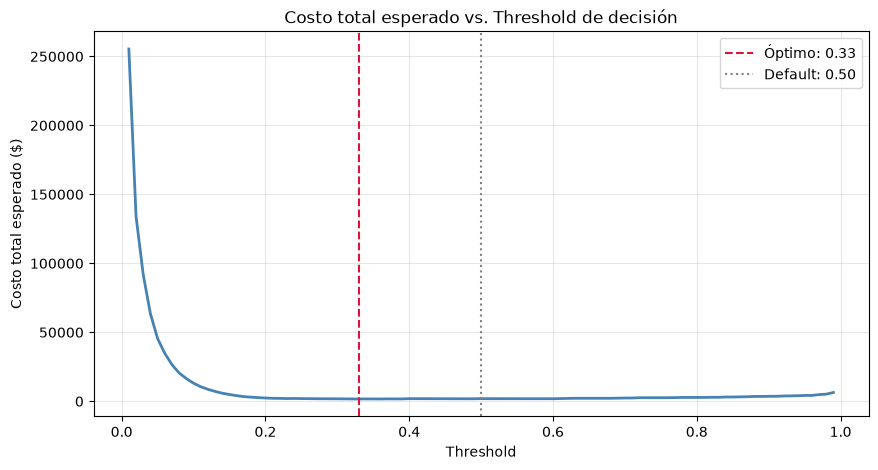

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='steelblue', linewidth=2)
plt.axvline(best_threshold, color='crimson', linestyle='--', label=f'Óptimo: {best_threshold:.2f}')
plt.axvline(0.50, color='gray', linestyle=':', label='Default: 0.50')
plt.xlabel('Threshold')
plt.ylabel('Costo total esperado ($)')
plt.title('Costo total esperado vs. Threshold de decisión')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [14]:
y_pred_optimal = (y_proba >= best_threshold).astype(int)
print(f"--- Classification Report (threshold={best_threshold:.2f}, óptimo por costo) ---")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fraude']))

--- Classification Report (threshold=0.33, óptimo por costo) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56887
      Fraude       0.50      0.83      0.62        75

    accuracy                           1.00     56962
   macro avg       0.75      0.91      0.81     56962
weighted avg       1.00      1.00      1.00     56962



## Corrección metodológica: threshold seleccionado con leakage

El threshold óptimo (0.33) fue calculado usando el mismo test set con el que luego se evaluó 
el modelo — esto constituye una forma de data leakage, ya que el test set debe reservarse 
exclusivamente para una evaluación final no contaminada por decisiones tomadas con esos mismos 
datos. Además, con solo 75 casos positivos en test, la curva de costo es ruidosa y el mínimo 
exacto podría no generalizar.

Se corrige dividiendo el set de entrenamiento en train/validation (manteniendo el orden temporal), 
seleccionando el threshold óptimo únicamente con el set de validación, y evaluando el resultado 
final una sola vez sobre el test set, que permanece intacto hasta el final.

In [15]:
val_split_point = int(len(train) * 0.8)
train_final = train.iloc[:val_split_point]
val = train.iloc[val_split_point:]

X_train_final = train_final[feature_cols]
y_train_final = train_final['Class']
X_val = val[feature_cols]
y_val = val['Class']

print(f"Train final: {len(train_final)} ({train_final['Class'].sum()} fraudes)")
print(f"Validation:  {len(val)} ({val['Class'].sum()} fraudes)")

Train final: 182276 (365 fraudes)
Validation:  45569 (52 fraudes)


In [16]:
model_final = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
model_final.fit(X_train_final, y_train_final)

y_val_proba = model_final.predict_proba(X_val)[:, 1]
avg_fraud_amount_val = val[val['Class']==1]['Amount'].mean()

costs_val = []
for t in thresholds:
    y_pred_t = (y_val_proba >= t).astype(int)
    fn = ((y_pred_t == 0) & (y_val.reset_index(drop=True) == 1)).sum()
    fp = ((y_pred_t == 1) & (y_val.reset_index(drop=True) == 0)).sum()
    costs_val.append(fn * avg_fraud_amount_val + fp * cost_fp)

best_threshold_val = thresholds[np.argmin(costs_val)]
print(f"Threshold óptimo (elegido con validation): {best_threshold_val:.2f}")

Threshold óptimo (elegido con validation): 0.21


In [17]:
y_test_proba_final = model_final.predict_proba(X_test)[:, 1]
y_test_pred_final = (y_test_proba_final >= best_threshold_val).astype(int)

print(f"--- Evaluación final sobre test (threshold={best_threshold_val:.2f} elegido con validation) ---")
print(classification_report(y_test, y_test_pred_final, target_names=['Normal', 'Fraude']))

--- Evaluación final sobre test (threshold=0.21 elegido con validation) ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56887
      Fraude       0.45      0.84      0.59        75

    accuracy                           1.00     56962
   macro avg       0.72      0.92      0.79     56962
weighted avg       1.00      1.00      1.00     56962



## Resultado final (metodológicamente correcto)

El threshold óptimo elegido usando el set de validation (0.21) difiere notablemente del threshold 
elegido con leakage sobre el propio test set (0.33) — una diferencia de 0.12 puntos, que confirma 
que la primera estimación estaba parcialmente sobreajustada al ruido de una muestra chica (75 
casos positivos).

Con el threshold correcto (0.21), el modelo alcanza 84% de recall y 45% de precision sobre el 
test set, evaluado una única vez sin contaminación. Este resultado es menos favorable que la 
estimación con leakage, pero es el número real y generalizable: el que efectivamente se sostendría 
en producción.

**Trade-off de negocio:** con este threshold, más de la mitad de las alertas generadas serán 
falsos positivos. Esto es aceptable dado que el costo de revisión manual ($5) es ~20x menor al 
costo de un fraude no detectado ($103), pero en un despliegue real valdría la pena complementar 
el modelo con reglas adicionales o un segundo filtro para reducir la carga operativa del equipo 
de revisión.

## Explicabilidad con SHAP

En un contexto bancario, no alcanza con que el modelo prediga bien — hay requisitos regulatorios 
y de auditoría que exigen poder explicar por qué una transacción específica fue marcada como 
sospechosa. SHAP (SHapley Additive exPlanations) asigna a cada variable una contribución numérica 
a la predicción, permitiendo trazar el razonamiento del modelo caso por caso.

Esta capa de explicabilidad es además la base para el módulo de IA generativa: los valores SHAP 
de cada alerta se traducirán a lenguaje natural mediante un LLM, generando explicaciones legibles 
para un analista de riesgo no técnico.

In [20]:
import shap

explainer = shap.TreeExplainer(model_final)

# Garantizamos incluir TODOS los casos de fraude del test + una muestra random de normales
fraud_cases = X_test[y_test == 1]
normal_sample = X_test[y_test == 0].sample(n=200, random_state=42)

X_test_sample = pd.concat([fraud_cases, normal_sample])
y_test_sample = pd.concat([y_test[y_test == 1], y_test[y_test == 0].loc[normal_sample.index]])

print(f"Muestra total: {len(X_test_sample)} ({y_test_sample.sum()} fraudes)")

shap_values = explainer.shap_values(X_test_sample)
print("Shape de shap_values:", np.array(shap_values).shape)

Muestra total: 275 (75 fraudes)
Shape de shap_values: (275, 30, 2)


In [21]:
# Nos quedamos con los SHAP values de la clase 1 (Fraude)
shap_values_fraud = shap_values[:, :, 1]
print(shap_values_fraud.shape)  # debería dar (200, 30)

(275, 30)


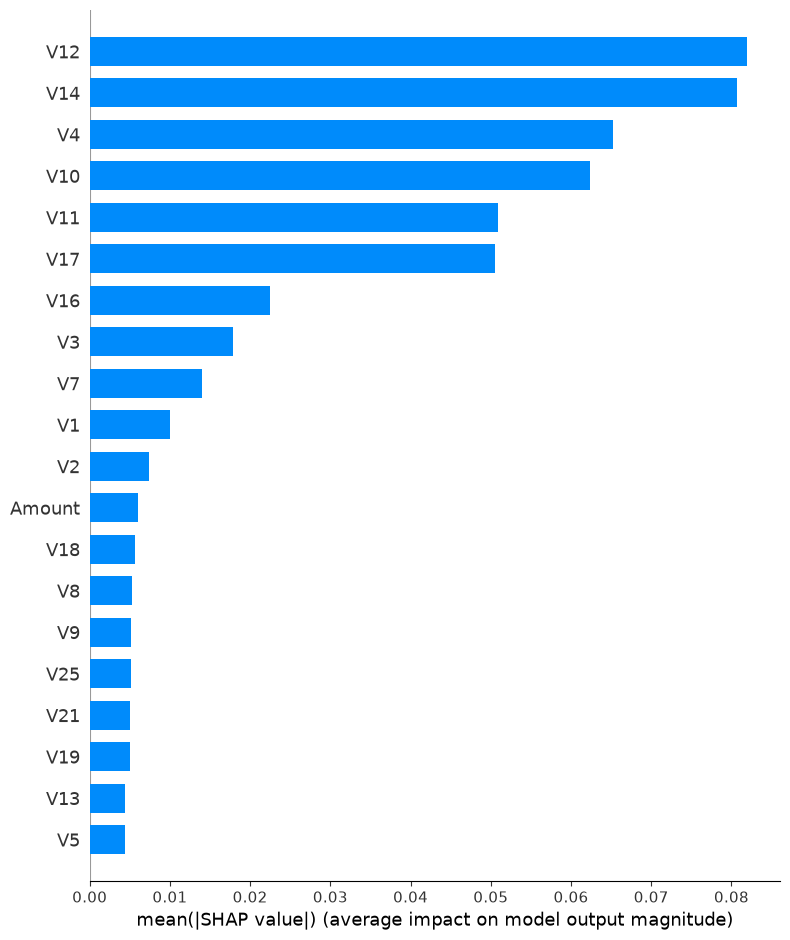

In [22]:
shap.summary_plot(shap_values_fraud, X_test_sample, plot_type='bar', show=True)

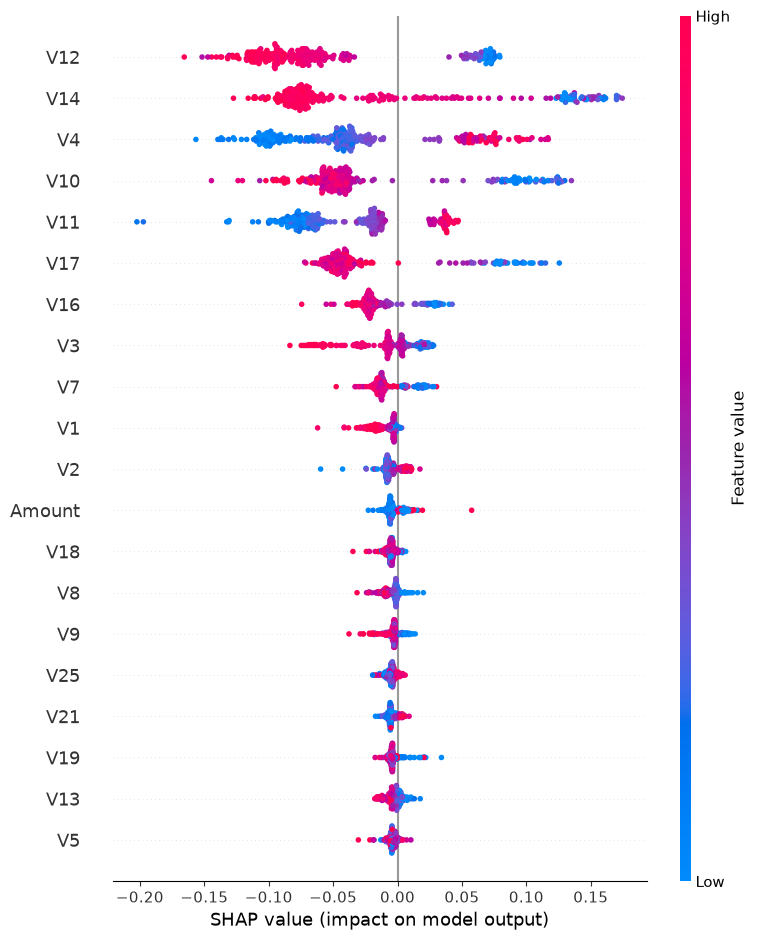

In [23]:
shap.summary_plot(shap_values_fraud, X_test_sample, show=True)

## Interpretación de SHAP

Las variables con mayor impacto en las predicciones de fraude son V12, V14, V4, V11, V10 y V17 
(componentes derivados de PCA, sin significado de negocio directo por razones de confidencialidad 
del dataset original).

El patrón de dirección es consistente: valores bajos de V12, V14, V10, V16 y V17 empujan la 
predicción hacia fraude, mientras que en V4 y V11 el patrón se invierte — valores altos aumentan 
la probabilidad de fraude. Esta asimetría de dirección entre variables es exactamente el tipo de 
información que un enfoque de "caja negra" (solo mirar accuracy) ocultaría, y que SHAP permite 
auditar caso por caso.

En un dataset con variables de negocio reales (no anonimizadas por PCA), este mismo análisis 
permitiría identificar patrones interpretables como "montos inusualmente altos en horario 
nocturno" — acá el equivalente son combinaciones de V12/V14/V4 que el modelo detecta pero que 
requieren traducción a lenguaje de negocio, que es justamente el rol del módulo de IA generativa 
que sigue a continuación.

In [24]:
fraud_indices = X_test_sample[y_test_sample == 1].index
case_idx = fraud_indices[0]
case_position = X_test_sample.index.get_loc(case_idx)
print(f"Caso de fraude encontrado: índice {case_idx}")
print(X_test_sample.loc[case_idx])
    

Caso de fraude encontrado: índice 229712
V1         0.908637
V2         2.849024
V3        -5.647343
V4         6.009415
V5         0.216656
V6        -2.397014
V7        -1.819308
V8         0.338527
V9        -2.819883
V10       -4.063098
V11        2.941190
V12       -6.151362
V13       -1.989529
V14       -9.150951
V15       -0.604290
V16       -1.952290
V17       -2.892555
V18       -0.912058
V19       -1.563740
V20        0.241921
V21        0.407260
V22       -0.397435
V23       -0.080006
V24       -0.168597
V25        0.465058
V26        0.210510
V27        0.648705
V28        0.360224
Amount     1.180000
Hour      16.000000
Name: 229712, dtype: float64


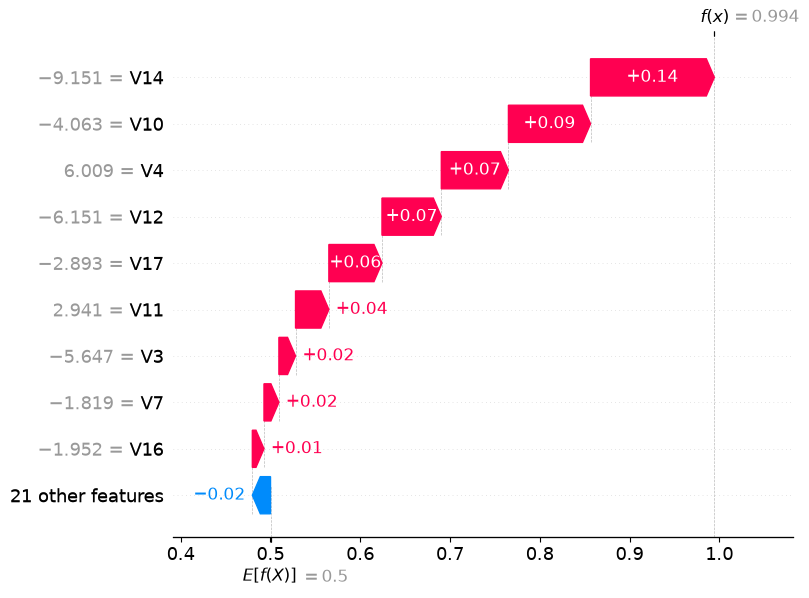

In [25]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_fraud[case_position],
        base_values=explainer.expected_value[1],
        data=X_test_sample.loc[case_idx],
        feature_names=X_test_sample.columns.tolist()
    )
)

In [26]:
shap_case = shap_values_fraud[case_position]
feature_names = X_test_sample.columns.tolist()

# Top 5 variables que más empujaron hacia fraude
top_features = sorted(
    zip(feature_names, shap_case, X_test_sample.loc[case_idx].values),
    key=lambda x: abs(x[1]),
    reverse=True
)[:5]

for feat, shap_val, feat_val in top_features:
    direction = "→ FRAUDE" if shap_val > 0 else "→ NORMAL"
    print(f"{feat}: valor={feat_val:.3f}, impacto SHAP={shap_val:.3f} {direction}")

V14: valor=-9.151, impacto SHAP=0.138 → FRAUDE
V10: valor=-4.063, impacto SHAP=0.091 → FRAUDE
V4: valor=6.009, impacto SHAP=0.075 → FRAUDE
V12: valor=-6.151, impacto SHAP=0.066 → FRAUDE
V17: valor=-2.893, impacto SHAP=0.059 → FRAUDE


## Traducción a lenguaje natural con LLM

Los valores SHAP son interpretables para un data scientist, pero no para un analista de riesgo 
sin formación técnica en ML. Se usa un LLM para traducir el output de SHAP de cada alerta a una 
explicación en lenguaje natural, cerrando la brecha entre el modelo y el usuario final del sistema.

In [27]:
from dotenv import load_dotenv
load_dotenv()

from huggingface_hub import InferenceClient
import os

client = InferenceClient(token=os.environ["HF_TOKEN"])

def explicar_alerta_llm(feature_impacts, monto, hora):
    prompt = f"""Sos un asistente de un equipo de riesgo bancario. Recibiste una alerta de fraude 
generada por un modelo de machine learning para una transacción de ${monto:.2f} ocurrida a las {hora}hs.

Las variables que más influyeron en la predicción (con su impacto SHAP) fueron:
{chr(10).join([f"- {feat}: valor={val:.2f}, impacto={shap:.3f}" for feat, shap, val in feature_impacts])}

Nota: estas variables son componentes anonimizados (PCA) del dataset original, sin significado 
de negocio explícito.

Redactá una explicación breve (3-4 líneas) en español, dirigida a un analista de riesgo NO técnico, 
que resuma por qué esta transacción fue marcada como sospechosa, sin usar jerga de machine learning."""

    response = client.chat_completion(
        messages=[{"role": "user", "content": prompt}],
        model="Qwen/Qwen2.5-7B-Instruct",
        max_tokens=300
    )
    return response.choices[0].message.content

explicacion = explicar_alerta_llm(top_features, X_test_sample.loc[case_idx]['Amount'], int(X_test_sample.loc[case_idx]['Hour']))
print(explicacion)

Esta transacción fue marcada como sospechosa porque el modelo detectó patrones que indican un alto riesgo de fraude. Específicamente, ciertos aspectos de la transacción, como los valores de las variables V14, V10, V4, V12 y V17, se alinearon con características comunes en transacciones fraudulentas, según el aprendizaje del modelo.


## Resultado del módulo de IA generativa

El LLM (Qwen2.5-7B vía Hugging Face Inference API) generó una explicación en lenguaje natural 
a partir de los valores SHAP de la transacción. La explicación es coherente pero relativamente 
genérica — menciona las variables influyentes sin profundizar en la magnitud relativa de cada 
una. Esto es esperable de un modelo de 7B parámetros con prompt simple; en un despliegue real, 
se podría mejorar con few-shot examples en el prompt, o usando un modelo más grande (ej. vía la 
API de Claude o GPT-4), a costa de mayor latencia/costo por alerta.

In [28]:
import joblib

joblib.dump(model_final, '../src/fraud_model.pkl')

# Exportamos también las predicciones del test set completo, para usar en Power BI
results = test.copy()
results['fraud_probability'] = model_final.predict_proba(X_test)[:, 1]
results['fraud_predicted'] = (results['fraud_probability'] >= best_threshold_val).astype(int)
results.to_csv('../data/test_results_for_powerbi.csv', index=False)

print("Modelo y resultados guardados correctamente")

Modelo y resultados guardados correctamente


## Costo final: threshold óptimo vs. default (evaluación limpia sobre test)

Se recalcula el costo total esperado sobre el test set intacto, comparando el threshold 
default (0.5) contra el threshold óptimo seleccionado correctamente con el set de validation 
(0.21) — esta vez sin ningún leakage, ya que ambos thresholds se aplican sobre datos no usados 
en su selección.

In [29]:
# Costo real por tipo de error, usando los fraudes del test set
avg_fraud_amount_test = test[test['Class']==1]['Amount'].mean()

def calcular_costo(y_true, y_proba, threshold, cost_fn, cost_fp):
    y_pred = (y_proba >= threshold).astype(int)
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    return fn * cost_fn + fp * cost_fp, fn, fp

costo_default, fn_default, fp_default = calcular_costo(
    y_test.values, y_test_proba_final, 0.50, avg_fraud_amount_test, cost_fp
)
costo_optimo, fn_optimo, fp_optimo = calcular_costo(
    y_test.values, y_test_proba_final, best_threshold_val, avg_fraud_amount_test, cost_fp
)

reduccion_pct = (costo_default - costo_optimo) / costo_default * 100

print(f"Threshold 0.50 (default):  costo=${costo_default:,.2f}  (FN={fn_default}, FP={fp_default})")
print(f"Threshold {best_threshold_val:.2f} (óptimo):    costo=${costo_optimo:,.2f}  (FN={fn_optimo}, FP={fp_optimo})")
print(f"\nReducción de costo: {reduccion_pct:.1f}%  (ahorro de ${costo_default - costo_optimo:,.2f})")

Threshold 0.50 (default):  costo=$1,998.08  (FN=19, FP=8)
Threshold 0.21 (óptimo):    costo=$1,621.68  (FN=12, FP=77)

Reducción de costo: 18.8%  (ahorro de $376.40)


## Conclusión

El ajuste del threshold de decisión de 0.50 a 0.21 (seleccionado correctamente sobre un set de 
validation, sin leakage) reduce el costo total esperado en 18.8% ($376.40 de ahorro sobre el 
período de test de 2 días), a costa de un trade-off explícito: se reducen los fraudes no 
detectados de 19 a 12 casos, aumentando las falsas alarmas de 8 a 77.

Este resultado no depende de un modelo más complejo ni de más datos — surge exclusivamente de 
alinear el punto de decisión del modelo con el costo real de negocio, un paso que la mayoría 
de los enfoques estándar (que usan threshold=0.5 por defecto) pasan por alto.